In [1]:
import numpy as np
import matplotlib.pyplot as plt

Vector norms

In [2]:
v = np.array([1,2,3])


In [3]:
# 2-norm

np.linalg.norm(v)

3.7416573867739413

In [4]:
# 1-norm
np.linalg.norm(v,ord=1)

6.0

In [5]:
# infinity norm
np.linalg.norm(v,ord=np.inf)

3.0

## Unit Balls

In [6]:
n = 100 # grid size

x = np.linspace(-1.5,1.5,n) # gives n evenly spaced points between -1.5 and 1.5

y = np.linspace(-1.5,1.5,n) # gives n evenly spaced points between -1.5 and 1.5



In [7]:
X,Y = np.meshgrid(x,y)

In [8]:
points = np.c_[X.flatten(),Y.flatten()].T

In [9]:
# compute the norm of each of the grid points

p =1

norms = np.linalg.norm(points,ord=p, axis=0).reshape(X.shape)

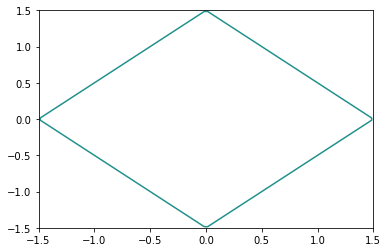

In [10]:
plt.contour(X,Y,norms, levels = 1)

## Induced matrix norms



In [11]:
A = np.array([[1,6],[-5,-1]])

In [12]:
A

array([[ 1,  6],
       [-5, -1]])

In [13]:
points_transformed = A.dot(points)

In [14]:
X_trans = points_transformed[0].reshape(X.shape)
Y_trans = points_transformed[1].reshape(X.shape)

(-10.5, 10.5, -9.0, 9.0)

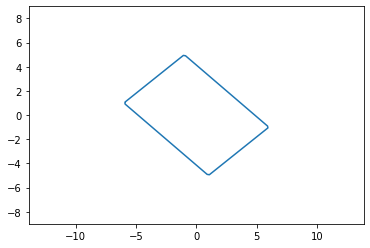

In [15]:
plt.contour(X_trans,Y_trans, norms, levels=[1],colors= 'C0')
plt.axis('equal')

For $A\in \mathbb{R}^{m\times n}$:

$\|A\|_1 = \max_{j=1,2,\ldots,n}\{\sum_{i=1}^m|a_{ij}|\}$ // max 1-norm of a column of $A$

$\|A\|_\inf = \max_{i=1,2,\ldots,m}\{\sum_{i=1}^n|a_{ij}|\}$  // max 1-norm of a row of $A$

$\|A\|_2$ = largest singular value of $A$.
****

Number of operations 

1-norm: $O(n^2)$

$\inf$-norm: $O(n^2)$

2-norm: $O(n^3)$

## Matrix Norms

In [16]:
A = np.array([[1,0],[2,-5],[3,2],[0,-3]])
A

array([[ 1,  0],
       [ 2, -5],
       [ 3,  2],
       [ 0, -3]])

In [17]:
np.linalg.norm(A,ord=2)

6.216840889123149

In [18]:
# frobenius norm
np.linalg.norm(A,ord='fro')

7.211102550927978

In [19]:
np.linalg.norm(A)

7.211102550927978

In [20]:
A = np.random.randn(1000,1000)

In [21]:
%%timeit
np.linalg.norm(A,ord=1)

489 µs ± 11.6 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [22]:
%%timeit
np.linalg.norm(A,ord=np.inf)

466 µs ± 1.31 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [23]:
%%timeit
np.linalg.norm(A,ord='fro')

82.7 µs ± 6.21 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [24]:
%%timeit
np.linalg.norm(A,ord=2)

130 ms ± 9.97 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## How sensitive is the solution x to perturbation in b?

Given $Ax=b$, if $b$ changes by $b->b+\Delta b$, we have $A(x+\Delta x)=b+\Delta(b)$

In [25]:
# Example 1

A = np.array([[5.1,1.8],[4.7,6.5]])
A

array([[5.1, 1.8],
       [4.7, 6.5]])

In [26]:
b = np.array([5.1,4.7])
b

array([5.1, 4.7])

In [27]:
np.linalg.solve(A,b)

array([1., 0.])

In [28]:
bb = b+np.array([0.01,0])

In [29]:
np.linalg.solve(A,bb)

array([ 1.00263264, -0.0019036 ])

In [30]:
np.linalg.norm(np.linalg.solve(A,bb)-np.linalg.solve(A,b))/np.linalg.norm(np.linalg.solve(A,b))

0.003248773532629359

In [31]:
### Example 2

A = np.array([[4.1,2.8],[9.7,6.6]])
A

array([[4.1, 2.8],
       [9.7, 6.6]])

In [32]:
b = np.array([4.1,9.7])

In [33]:
np.linalg.solve(A,b)

array([1., 0.])

In [34]:
bb = b+np.array([0.01,0])

In [35]:
np.linalg.solve(A,bb)

array([0.34, 0.97])

In [36]:
np.linalg.norm(np.linalg.solve(A,bb)-np.linalg.solve(A,b))/np.linalg.norm(np.linalg.solve(A,b))

1.1732433677630363

### Theorem:

Let $A$ be invertible, and let $x, \hat{x}$ be the solutions of $Ax=b (1), A\hat{x}=b+\Delta{b}  (2)$

Then $\|x-\hat{x}\|/\|x\|\leq \|A\|\|A^{-1}\|\frac{\|\Delta b\|}{\|b\|}$.

This links the relative of $x$ and $b$ via amplification factor $\|A\|\|A^{-1}\|$ (our condition number!)

Proof: from (2) - (1), we get $A\Delta(x) = \Delta b$. $A$ is invertible, so we then have $\Delta x = A^{-1}\Delta b$.

Then $\|\Delta x\| = \|A^{-1}\Delta b\|\leq \|A^{-1}\|\|\Delta b\|$

So $\frac{\|\Delta x\|}{\|x\|}\leq \frac{\|A^{-1}\Delta b\|\leq \|A^{-1}\|\|\Delta b\|}{\|x\|}$  (3).

From (1) we obtain $\|b\|=\|Ax\|\leq \|A\|\|x\|$, so $\|x\|\geq \frac{\|b\|}{\|A\|}$

Then we get $\frac{\|\Delta x\|}{\|x\|}\leq \frac{\|A^{-1}\Delta b\|\leq \|A^{-1}\|\|\Delta b\|}{\|x\|} \leq \frac{\|A^{-1}\Delta b\|\leq \|A^{-1}\|\|\Delta b\|}{\frac{\|b\|}{\|A\|}}=\|A^{-1}\|\|A\|\frac{\|\Delta b\|}{\|b\|}$

If $\kappa(A)>>1$, then we say that $A$ is $\textit{ill-conditioned}$.
****
## Hilbert Matrices

In [37]:
def hilbert(n):
    H = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            H[i,j]=1/(i+j+1)
            
    return H

In [38]:
hilbert(5)

array([[1.        , 0.5       , 0.33333333, 0.25      , 0.2       ],
       [0.5       , 0.33333333, 0.25      , 0.2       , 0.16666667],
       [0.33333333, 0.25      , 0.2       , 0.16666667, 0.14285714],
       [0.25      , 0.2       , 0.16666667, 0.14285714, 0.125     ],
       [0.2       , 0.16666667, 0.14285714, 0.125     , 0.11111111]])

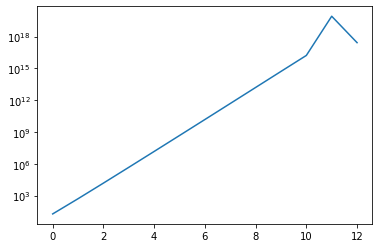

In [39]:
condition_numbers = []

for n in range(2,15):
    H = hilbert(n)
    condition_numbers.append(np.linalg.cond(H))
    
plt.semilogy(condition_numbers)

## Estimating Condition Numbers

Issue with calculating $\kappa(A)=\|A\|\|A^{-1}\|$ is finding the inverse

For any vector $w$ with $\|w\|_1=1$, estimate by $\kappa(A)\geq \|A\|_1\|A^{-1}w\|_1$

In [40]:
def my_lu(A,pivoting=None):
    
    """
    This function factors A = LU (if pivoting=None; default) or PA = LU (if pivoting='partial')
    INPUT:
        matrix A
    OUTPUT:
        permutation vector p (if pivoting == 'partial')
        lower triangular factor L
        upper triangular factor U
    """
    
    n,m = A.shape # size of matrix A
    if m!=n: # check if A is square
        print('WARNING: A must be a square matrix') # print a warning massage
        return  
    
    # initialize factors L and U
    U = A.copy()
    L = np.identity(n)
    
    # initialize permutation vector p = [0,1,...,n-1]
    if pivoting == 'partial':
        p = np.arange(n)
    
    # GAUSSIAN ELIMINATION 
    for i in range(n):  # loop over columns 1,...,n (first loop)
        if pivoting=='partial':
            # Find the entry with largest absolute value
            row2swap = i + np.argmax(np.abs(U[i:n,i]))
            # swap rows of U
            U[[row2swap,i],i:n] = U[[i,row2swap],i:n]
            # swap multipliers
            L[[row2swap,i],0:i] = L[[i,row2swap],0:i] 
            # update permutation vector p
            p[[row2swap,i]]=p[[i,row2swap]]
        # multipliers 
        L[i+1:n,i] = U[i+1:n,i]/U[i,i] 
        # update U
        U[i+1:n,i] = 0 
        U[i+1:n,i+1:n] = U[i+1:n,i+1:n] - np.outer(L[i+1:n,i],U[i,i+1:n]) # update U
    
    if pivoting=='partial':
        return L,U,p
    else:
        return L,U

In [41]:
def my_solve_plu(L,U,p,b,pivoting=None):
    'given PA = LU, this function solves Ax=b'

    # size of the problem
    n = len(b)
    
    # initialize vectors x and y
    y = np.zeros(n)
    x = np.zeros(n)
    
    # permute b
    bp = b[p]

    # solve Ly = bp
    for i in range(n):
        y[i] = bp[i] - L[i,0:i].dot(y[0:i])

    # solve Ux = y
    for i in reversed(range(n)): # i = n,...,1
        x[i] = (y[i] - U[i,i+1:n].dot(x[i+1:n]))/U[i,i]

    return x

In [42]:
def condest(A,L,U,p):
    # given PA = LU, it estimates  the condition number of A
    
    # size
    n = len(p)
    # norm of A
    normA = np.linalg.norm(A,ord = 1)
    # norm of A inverse
    normAinv = 0
    for k in range(10):  # number of iterations is small compared to n
        w = np.random.randn(n)
        w = w/np.linalg.norm(w,ord=1)
        x = my_solve_plu(L,U,p,w)
        if np.linalg.norm(x,ord=1)> normAinv:
            normAinv = np.linalg.norm(x,ord=1)
            
    return normA*normAinv

In [43]:
# test 1: random matrix
A = np.random.randn(200,200)
L,U,p = my_lu(A,pivoting='partial')
condest(A,L,U,p)

675.0758473193625

In [44]:
np.linalg.cond(A, p=1)

8261.016304547651

In [45]:
# test 2: Hilbert matrices

A = hilbert(15)
L,U,p = my_lu(A,pivoting='partial')
condest(A,L,U,p)

2.6451445461713306e+17

In [46]:
np.linalg.cond(A, p=1)

7.737527419409158e+17

In [47]:
# test 3

A = np.random.randn(200,200)
A[:,0] = A[:,1]+A[:,2]+1e-10*np.random.randn(200)

L,U,p = my_lu(A,pivoting='partial')
condest(A,L,U,p)

165564655006.07684

In [48]:
np.linalg.cond(A, p=1)

3264284218453.0396

### How sensitive is x to perturbations in A?

$Ax=b$ -> $(A+\Delta A)(x+\Delta x) =b$ 

Note: $A+\Delta A$ may be singular. We need the following theorem:

Theorem: if $A$ is invertible, and $\frac{\|\Delta A\|}{\|A\|}<\frac{1}{\kappa{A}}=\frac{1}{\|A\|\|A^{-1}\|}$, then $A+\Delta A$ is invertible.

We will prove that if $A+\Delta A$ is singular, then $\frac{\|\Delta A\|}{\|A\|}\geq \frac{1}{\kappa{A}}$.

If $A+\Delta A$ is singular, then there exists a nonzero $x$ such that $(A+\Delta A)x = 0$. That is, $x$ satisfies $Ax+\Delta x = 0$ or $Ax=-\Delta A x$. As $A$ is invertible, we have that $x = -A^{-1}\Delta Ax$. So $\|x\|=\\A^{-1}\Delta A x\| \geq \|A^{-1}\|\|\Delta A\|\|x\|$.

Dividing by the norm of $x$ yields $1\leq \|A^{-1}\|\|\Delta A\|$, which implies $\frac{\|\Delta A\|}{\|A\|}\geq \frac{1}{\kappa{A}}$ as needed.

Theorem: Let $A$ be invertible, and let $x$ and $\hat{x} = x+\Delta x$ be the solutions of 
$$
Ax=b , (A+\Delta A)(x+\Delta x) =b
$$

If $\frac{\|\Delta A\|}{\|A\|}$, then $\frac{\|\Delta x\|}{\|x\|}\leq\frac{1}{1-\kappa(A)\frac{\|\Delta A\|}{\|A\|}}\kappa (A)\cdot \frac{\|\Delta A\|}{\|A\|}$

Proof: Just expand it, find difference of two equations, solve for $A\Delta x$.

### Error Bounds

$x$ is the solution of $Ax = b$ (which we do not know)

$\hat{x}$ is the computed solution.

Goal: estimate $\frac{\|x-\hat{x}\|}{\|x\|}$

#### A posteriori error bound

(we need the computed solution.

We'll use the *residual*, $r=A\hat{x}-b$, which equals $0$ when $\hat{x} = x$.}

Question: Does a small residual imply a small relative error?

Answer: not always

Theorem 2: The computed solution $\hat{x}$ is the exact solution to $A+\Delta A)\hat{x} = b$ with 

$$
\Delta A = \frac{-1}{\|x\|_2^2}r\hat{x}^T
$$

proof: ETS $A+\Delta A)\hat{x} = b$

$$
    (A+\Delta A)\hat{x}  = (A+\frac{-1}{\|x\|_2^2}r\hat{x}^T)\hat{x} =  A\hat{x}-r = b
$$

The norm of $\Delta A$ depends on the norm we are using.

1-norm: $\|\Delta A\|_1 = \frac{1}{\|x\|_2^2}\|r\|_1\|\hat{x}\|_\infty$

$\infty$-norm: $\|\Delta A\|_\infty = \frac{1}{\|x\|_2^2}\|r\|_\infty\|\hat{x}\|_1$

Frobenius norm: $\|\Delta A\|_F = \frac{1}{\|x\|_2^2}\|r\|_2\|\hat{x}\|_2=\frac{\|r\|_2}{\|x\|_2}$

2-norm: $\|\Delta A\|_2 = \frac{1}{\|x\|_2^2}\|r\|_2\|\hat{x}\|_2=\frac{\|r\|_2}{\|x\|_2}$


$\frac{\|\Delta A\|_2}{\|A\|_2}=\frac{\|r\|_2}{\|A\|_2\|x\|_2}$

Theorems 1 and 2 combine to say the following:

$$
\frac{\|x-\hat{x}\|_2}{\|x\|_2} \leq \kappa(A) \frac{\|\Delta A\|_2}{\|A\|_2} = \kappa(A)\frac{\|r\|_2}{\|A\|_2\|\hat{x\|_2}}
$$

Upshot: Small relative residula + well-conditioned matrix -> small error

## Relative Error Bounds

   ### Example 1: Hilbert matrices or the futility of solving ill-conditioned linear systems

In [49]:
### Example 3 i got bored

n = 5

A = np.eye(n)+np.tril(-np.ones((n,n)),-1)

A[:,n-1] = 1


A

array([[ 1.,  0.,  0.,  0.,  1.],
       [-1.,  1.,  0.,  0.,  1.],
       [-1., -1.,  1.,  0.,  1.],
       [-1., -1., -1.,  1.,  1.],
       [-1., -1., -1., -1.,  1.]])

In [50]:
n = 60

A = np.eye(n)+np.tril(-np.ones((n,n)),-1)

A[:,n-1] = 1

In [51]:
np.linalg.cond(A)

26.803535522538088

In [52]:
x = np.ones(n)
b = A.dot(x)

In [53]:
# solve Ax = b
xhat = np.linalg.solve(A,b)

In [54]:
# relative residual

r = A.dot(xhat)-b

rel_res = np.linalg.norm(r)/(np.linalg.norm(A)*np.linalg.norm(xhat))

rel_res

0.02562857991356098

In [55]:
# error estimate

np.linalg.norm(x-xhat)/np.linalg.norm(x)

0.3162277660168379

In [56]:
# error

np.linalg.norm(x-xhat)/np.linalg.norm(x)

0.3162277660168379